## Install

In [1]:
!pip install ydata-profiling setuptools pandas google-cloud-bigquery google-auth pyarrow

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 2.4 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 2.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 2.8 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import os
from ydata_profiling import ProfileReport
from google.cloud import bigquery
from google.oauth2 import service_account


## 0. Load Data

In [4]:
# Tạo DataFrame từ các file CSV
olist_orders_dataset = pd.read_csv('csv/olist_orders_dataset.csv')    
olist_customers_dataset = pd.read_csv('csv/olist_customers_dataset.csv')
olist_geolocation_dataset = pd.read_csv('csv/olist_geolocation_dataset.csv')
olist_order_payments_dataset = pd.read_csv('csv/olist_order_payments_dataset.csv')
product_category_name_translation = pd.read_csv('csv/product_category_name_translation.csv')
olist_order_items_dataset = pd.read_csv('csv/olist_order_items_dataset.csv')
olist_order_reviews_dataset = pd.read_csv('csv/olist_order_reviews_dataset.csv')
olist_products_dataset = pd.read_csv('csv/olist_products_dataset.csv')
olist_sellers_dataset = pd.read_csv('csv/olist_sellers_dataset.csv')

dfs = {
    "olist_orders_dataset": olist_orders_dataset,
    "olist_customers_dataset": olist_customers_dataset,
    "olist_geolocation_dataset": olist_geolocation_dataset,
    "olist_order_payments_dataset": olist_order_payments_dataset,
    "product_category_name_translation": product_category_name_translation,
    "olist_order_items_dataset": olist_order_items_dataset,
    "olist_order_reviews_dataset": olist_order_reviews_dataset,
    "olist_products_dataset": olist_products_dataset,
    "olist_sellers_dataset": olist_sellers_dataset
}

summary = pd.DataFrame([
    {"Tên DataFrame": name, "Số dòng": df.shape[0], "Số cột": df.shape[1]}
    for name, df in dfs.items()
])

#summary.sort_values(by="Tên DataFrame", inplace=True)
display(summary)  

,Tên DataFrame,Số dòng,Số cột
0,olist_orders_dataset,99441,8
1,olist_customers_dataset,99441,5
2,olist_geolocation_dataset,1000163,5
3,olist_order_payments_dataset,103886,5
4,product_category_name_translation,71,2
5,olist_order_items_dataset,112650,7
6,olist_order_reviews_dataset,99224,7
7,olist_products_dataset,32951,9
8,olist_sellers_dataset,3095,4


In [5]:
# Thông tin kết nối BigQuery
project_id = "fsds-469803"
dataset_id = "dwh_olist"
key_path = os.path.expanduser('~/BusinessIntelligence/fsds-469803-50393ed26312.json')

# Tạo client BigQuery
credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=project_id)

# Cấu hình ghi đè bảng nếu đã tồn tại
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,  #WRITE_APPEND,
    autodetect=True,  
)

# Load DataFrame vào BigQuery
table_id = "olist_orders_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_orders_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_customers_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_customers_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_geolocation_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_geolocation_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_order_payments_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_order_payments_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "product_category_name_translation"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(product_category_name_translation, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_order_items_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_order_items_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_order_reviews_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_order_reviews_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_products_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_products_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")

table_id = "olist_sellers_dataset"
table_ref = f"{project_id}.{dataset_id}.{table_id}"
job = client.load_table_from_dataframe(olist_sellers_dataset, table_ref, job_config=job_config)
job.result()  
print(f"✅ Đã tải {job.output_rows} dòng vào bảng {table_ref}")


/home/dongtd6/BusinessIntelligence/ProjectFinal/BIFinalProject/.venv/lib/python3.9/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Đã tải 99441 dòng vào bảng fsds-469803.dwh_olist.olist_orders_dataset


/home/dongtd6/BusinessIntelligence/ProjectFinal/BIFinalProject/.venv/lib/python3.9/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Đã tải 99441 dòng vào bảng fsds-469803.dwh_olist.olist_customers_dataset


/home/dongtd6/BusinessIntelligence/ProjectFinal/BIFinalProject/.venv/lib/python3.9/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


...

✅ Đã tải 99224 dòng vào bảng fsds-469803.dwh_olist.olist_order_reviews_dataset


/home/dongtd6/BusinessIntelligence/ProjectFinal/BIFinalProject/.venv/lib/python3.9/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Đã tải 32951 dòng vào bảng fsds-469803.dwh_olist.olist_products_dataset


/home/dongtd6/BusinessIntelligence/ProjectFinal/BIFinalProject/.venv/lib/python3.9/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Đã tải 3095 dòng vào bảng fsds-469803.dwh_olist.olist_sellers_dataset


## 1. Check Data

In [6]:
olist_order_items_dataset.isna().all(axis=1).sum()
olist_order_items_dataset.duplicated().sum()


np.int64(0)

In [ ]:
# Kiểm tra giá trị null trong các DataFrame
null_summary = pd.DataFrame(columns=["Table", "Column", "Missing_Count", "Missing_%"])

for name, df in dfs.items():
    nulls = df.isnull().sum()
    total = len(df)
    percent = (nulls / total * 100).round(2)
    
    temp = pd.DataFrame({
        "Table": name,
        "Column": nulls.index,
        "Missing_Count": nulls.values,
        "Missing_%": percent.values
    })Load
    
    null_summary = pd.concat([null_summary, temp], ignore_index=True)

# Lọc chỉ những cột có giá trị null
null_summary = null_summary[null_summary["Missing_Count"] > 0]    

# Sắp xếp cho dễ đọc
null_summary = null_summary.sort_values(by=["Missing_%", "Table"], ascending=[False, True])

# Hiển thị bảng tóm tắt
display(null_summary)

/tmp/ipykernel_595240/634157809.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  null_summary = pd.concat([null_summary, temp], ignore_index=True)


,Table,Column,Missing_Count,Missing_%
35,olist_order_reviews_dataset,review_comment_title,87656,88.34
36,olist_order_reviews_dataset,review_comment_message,58247,58.70
6,olist_orders_dataset,order_delivered_customer_date,2965,2.98
40,olist_products_dataset,product_category_name,610,1.85
41,olist_products_dataset,product_name_lenght,610,1.85
42,olist_products_dataset,product_description_lenght,610,1.85
43,olist_products_dataset,product_photos_qty,610,1.85
5,olist_orders_dataset,order_delivered_carrier_date,1783,1.79
4,olist_orders_dataset,order_approved_at,160,0.16
44,olist_products_dataset,product_weight_g,2,0.01


In [14]:
olist_orders_dataset.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [5]:
olist_customers_dataset.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [ ]:
olist_geolocation_dataset.describe()


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [7]:
olist_order_payments_dataset.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [8]:
product_category_name_translation.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [9]:
olist_order_items_dataset.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [10]:
olist_order_reviews_dataset.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [11]:
olist_products_dataset.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [12]:
olist_sellers_dataset.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [ ]:
# Đọc dữ liệu từ Big Querry
client = bigquery.Client()
tables = [
    "dongtd3.olist.olist_orders_dataset",
    "dongtd3.olist.olist_customers_dataset",
    "dongtd3.olist.olist_geolocation_dataset",
    "dongtd3.olist.olist_order_payments_dataset",
    "dongtd3.olist.product_category_name_translation",
    "dongtd3.olist.olist_order_items_dataset",
    "dongtd3.olist.olist_order_reviews_dataset",
    "dongtd3.olist.olist_products_dataset",
    "dongtd3.olist.olist_sellers_dataset"
]

for table in tables:
    print(f"\n🧪 Checking table: {table}")
    query = f"""
    SELECT
      COUNT(*) AS total_rows
    FROM `{table}`
    """
    result = client.query(query).to_dataframe()
    print(result)



🧪 Checking table: dongtd3.OlistDatabase.olist_orders_dataset


ValueError: Please install the 'db-dtypes' package to use this function.

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Pandas Profiling Report")/home/dongtd6/Pictures/Screenshots/Screenshot from 2025-10-18 11-19-19.png
profile.to_file("your_report.html")

In [4]:
# merge data
comp_data = (
    eve
    .merge(itm, left_on='item_id', right_on='id', how='outer')
    .merge(usr, left_on='user_id', right_on='id', how='inner')
)

## Bước 1: Thực hiện Data Dictionary & Data Quality Assessment

### About data

In [5]:
# values/keys of columns
for column in comp_data.columns:
    unique = comp_data[column].unique()
    print(f"Unique value of {column}: {unique}")

Unique value of user_id: [  5115  10904  29457 ... 260725  18261   3772]
Unique value of ga_session_id: [17001 16401 17113 ... 18001 17969 17918]
Unique value of country: ['US' 'TR' 'KR' 'MT' 'ES' 'MX' 'IL' nan 'IN' 'CA' 'GB' 'PL' 'MY' 'QA' 'TW'
 'GR' 'ID' 'RU' 'DE' 'PE' 'FR' 'PK' 'EG' 'JP' 'BD' 'SE' 'HN' 'RS' 'UY'
 'NL' 'IT' 'SG' 'CN' 'HK' 'IE' 'CO' 'TH' 'HR' 'BR' 'AU' 'LK' 'PT' 'CZ'
 'CY' 'AT' 'BA' 'DK' 'RO' 'DZ' 'SA' 'NZ' 'UA' 'NG' 'SK' 'BY' 'BG' 'VN'
 'CH' 'PH' 'SI' 'AR' 'MA' 'GT' 'IQ' 'NO' 'KZ' 'SV' 'LV' 'CL' 'PR' 'BE'
 'PS' 'FI' 'AE' 'DO' 'KW' 'LU' 'GH' 'LT' 'EC' 'GE' 'AM' 'JO' 'XK' 'MK'
 'PY' 'ZA' 'IS' 'MN' 'TN' 'AZ' 'HU' 'KH' 'CR' 'VE' 'TT' 'BO' 'PA' 'EE'
 'AL' 'JM' 'BS' 'NP' 'MO' 'LB' 'BH' 'MM' 'KE' 'OM']
Unique value of device: ['mobile' 'desktop' 'tablet']
Unique value of type: ['purchase' 'add_to_cart' 'begin_checkout']
Unique value of item_id: [   0    1    2 ... 1378 1379 1380]
Unique value of date_x: ['2020-11-02 12:05:14' '2020-11-03 08:19:14' '2020-11-05 18:02:19' ...


In [6]:
# data info
comp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758884 entries, 0 to 758883
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        758884 non-null  int64 
 1   ga_session_id  758884 non-null  int64 
 2   country        754329 non-null  object
 3   device         758884 non-null  object
 4   type           758884 non-null  object
 5   item_id        758884 non-null  int64 
 6   date_x         758884 non-null  object
 7   id_x           758884 non-null  int64 
 8   name           758884 non-null  object
 9   brand          758884 non-null  object
 10  variant        122624 non-null  object
 11  category       758884 non-null  object
 12  price_in_usd   758884 non-null  int64 
 13  id_y           758884 non-null  int64 
 14  ltv            758884 non-null  int64 
 15  date_y         758884 non-null  object
dtypes: int64(7), object(9)
memory usage: 92.6+ MB


### Check duplicate values

In [7]:
dup = comp_data[comp_data.duplicated()]
dup.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39498 entries, 28 to 754587
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   user_id        39498 non-null  int64 
 1   ga_session_id  39498 non-null  int64 
 2   country        39234 non-null  object
 3   device         39498 non-null  object
 4   type           39498 non-null  object
 5   item_id        39498 non-null  int64 
 6   date_x         39498 non-null  object
 7   id_x           39498 non-null  int64 
 8   name           39498 non-null  object
 9   brand          39498 non-null  object
 10  variant        38341 non-null  object
 11  category       39498 non-null  object
 12  price_in_usd   39498 non-null  int64 
 13  id_y           39498 non-null  int64 
 14  ltv            39498 non-null  int64 
 15  date_y         39498 non-null  object
dtypes: int64(7), object(9)
memory usage: 5.1+ MB


In [8]:
# drop duplicates
test = comp_data.drop_duplicates()
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 719386 entries, 0 to 758883
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        719386 non-null  int64 
 1   ga_session_id  719386 non-null  int64 
 2   country        715095 non-null  object
 3   device         719386 non-null  object
 4   type           719386 non-null  object
 5   item_id        719386 non-null  int64 
 6   date_x         719386 non-null  object
 7   id_x           719386 non-null  int64 
 8   name           719386 non-null  object
 9   brand          719386 non-null  object
 10  variant        84283 non-null   object
 11  category       719386 non-null  object
 12  price_in_usd   719386 non-null  int64 
 13  id_y           719386 non-null  int64 
 14  ltv            719386 non-null  int64 
 15  date_y         719386 non-null  object
dtypes: int64(7), object(9)
memory usage: 93.3+ MB


### Missing Values

In [9]:
print(test.isna().sum())

user_id               0
ga_session_id         0
country            4291
device                0
type                  0
item_id               0
date_x                0
id_x                  0
name                  0
brand                 0
variant          635103
category              0
price_in_usd          0
id_y                  0
ltv                   0
date_y                0
dtype: int64


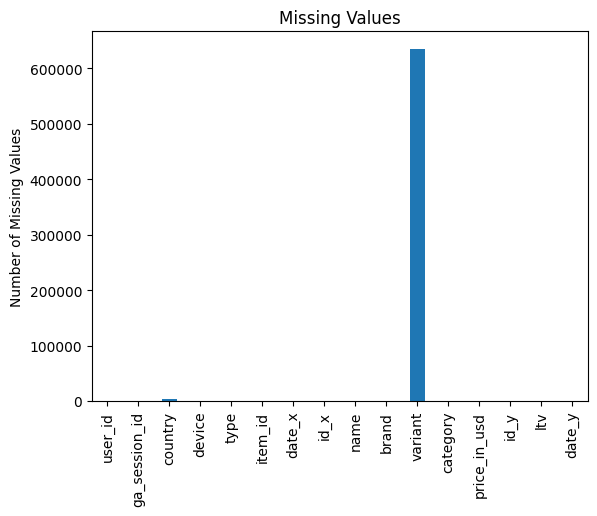

In [10]:
import matplotlib.pyplot as plt

test.isna().sum().plot(kind='bar')
plt.title('Missing Values')
plt.ylabel('Number of Missing Values')
plt.show()

user_id           0.000000
ga_session_id     0.000000
country           0.596481
device            0.000000
type              0.000000
item_id           0.000000
date_x            0.000000
id_x              0.000000
name              0.000000
brand             0.000000
variant          88.284037
category          0.000000
price_in_usd      0.000000
id_y              0.000000
ltv               0.000000
date_y            0.000000
dtype: float64


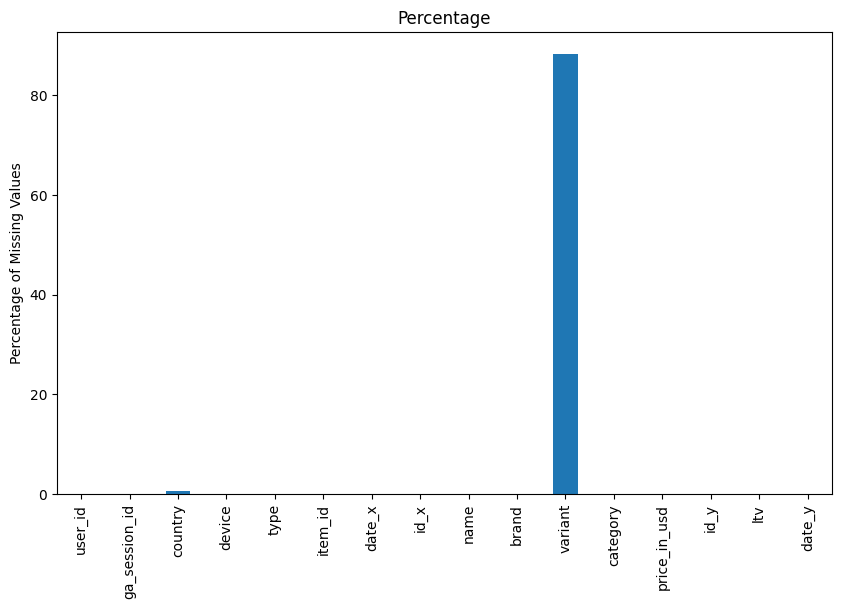

In [11]:
missing_percentage = (test.isnull().sum() / len(test)) * 100
print(missing_percentage)
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage')
plt.ylabel('Percentage of Missing Values')
plt.show()

- Missing value of "country": 0.6% (missing value < 4-5% có thể loại bỏ các hàng)
- Missing value of "variant": 88.3% (missing value > 60% có thẻ loại bỏ cột/biến)

In [12]:
# data quality assessment
test.describe()

,user_id,ga_session_id,item_id,id_x,price_in_usd,id_y,ltv
count,719386.000000,719386.000000,719386.000000,719386.000000,719386.000000,719386.000000,719386.000000
mean,30215.532934,3609.655549,920.030530,920.030530,25.043379,30215.532934,59.025124
std,56350.644850,3916.364635,250.526773,250.526773,20.941856,56350.644850,119.815095
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,8420.000000,624.000000,923.000000,923.000000,12.000000,8420.000000,0.000000
50%,17360.000000,2098.500000,975.000000,975.000000,22.000000,17360.000000,0.000000
75%,25914.000000,5350.000000,1042.000000,1042.000000,30.000000,25914.000000,76.000000
max,270145.000000,18033.000000,1380.000000,1380.000000,313.000000,270145.000000,1530.000000


In [13]:
test.nunique()

,0
user_id,14701
ga_session_id,18034
country,108
device,3
type,3
item_id,1381
date_x,78040
id_x,1381
name,421
brand,5


In [14]:
# đổi tên các columns
test = test.rename(columns={'date_x': 'date_session', 'name': 'item_name', 'date_y': 'user_create_date'})
# xóa những columns bị trùng lặp
test.drop(columns=['id_x'], inplace=True)
test.drop(columns=['id_y'], inplace=True)
test.columns

Index(['user_id', 'ga_session_id', 'country', 'device', 'type', 'item_id',
       'date_session', 'item_name', 'brand', 'variant', 'category',
       'price_in_usd', 'ltv', 'user_create_date'],
      dtype='object')

## Bước 2: Xử lí dữ liệu missing values

In [15]:
# drop cột "variant" vì missing value > 60%
test.drop(columns=['variant'], inplace=True)

In [16]:
# chỉ lấy các rows không bị missing value ở cột "country"
comp_data = test[test['country'].notnull()]
comp_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 715095 entries, 0 to 758883
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           715095 non-null  int64 
 1   ga_session_id     715095 non-null  int64 
 2   country           715095 non-null  object
 3   device            715095 non-null  object
 4   type              715095 non-null  object
 5   item_id           715095 non-null  int64 
 6   date_session      715095 non-null  object
 7   item_name         715095 non-null  object
 8   brand             715095 non-null  object
 9   category          715095 non-null  object
 10  price_in_usd      715095 non-null  int64 
 11  ltv               715095 non-null  int64 
 12  user_create_date  715095 non-null  object
dtypes: int64(5), object(8)
memory usage: 76.4+ MB


In [17]:
from datetime import datetime
import time
# đưa dữ liệu của cột "date_session" & "user_create_date" về định dạng datetime
comp_data['date_session'] = pd.to_datetime(comp_data['date_session'], format='%Y-%m-%d %H:%M:%S')
comp_data['user_create_date'] = pd.to_datetime(comp_data['user_create_date'], format='%Y-%m-%d %H:%M:%S')

# thêm 2 cột "hour_session" và "day_of_week"
comp_data['hour_session'] = comp_data['date_session'].dt.hour
comp_data['day_of_week'] = comp_data['date_session'].dt.day_name()
comp_data.head(10)

<ipython-input-17-d934b18ba508>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_data['date_session'] = pd.to_datetime(comp_data['date_session'], format='%Y-%m-%d %H:%M:%S')
<ipython-input-17-d934b18ba508>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_data['user_create_date'] = pd.to_datetime(comp_data['user_create_date'], format='%Y-%m-%d %H:%M:%S')
<ipython-input-17-d934b18ba508>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

,user_id,ga_session_id,country,device,type,item_id,date_session,item_name,brand,category,price_in_usd,ltv,user_create_date,hour_session,day_of_week
0,5115,17001,US,mobile,purchase,0,2020-11-02 12:05:14,Google Land & Sea Cotton Cap,Google,Apparel,14,85,2020-11-02 11:53:43,12,Monday
1,10904,16401,TR,desktop,purchase,0,2020-11-03 08:19:14,Google Land & Sea Cotton Cap,Google,Apparel,14,40,2020-09-06 09:19:37,8,Tuesday
2,29457,17113,KR,mobile,purchase,0,2020-11-05 18:02:19,Google Land & Sea Cotton Cap,Google,Apparel,14,33,2020-11-05 17:51:34,18,Thursday
3,30148,16175,MT,desktop,purchase,0,2020-11-05 18:33:59,Google Land & Sea Cotton Cap,Google,Apparel,14,517,2020-09-27 21:00:27,18,Thursday
4,32087,15869,US,desktop,purchase,0,2020-11-06 03:39:46,Google Land & Sea Cotton Cap,Google,Apparel,14,55,2020-11-06 03:15:36,3,Friday
5,18184,16368,ES,desktop,purchase,0,2020-11-09 11:16:13,Google Land & Sea Cotton Cap,Google,Apparel,14,86,2020-09-18 18:30:01,11,Monday
6,2418,15838,US,mobile,purchase,0,2020-11-16 01:10:12,Google Land & Sea Cotton Cap,Google,Apparel,14,95,2020-11-16 00:36:18,1,Monday
7,2406,2748,MX,desktop,add_to_cart,0,2020-11-17 00:29:16,Google Land & Sea Cotton Cap,Google,Apparel,14,96,2020-10-01 08:02:17,0,Tuesday
8,2406,2748,MX,desktop,add_to_cart,0,2020-11-17 00:30:31,Google Land & Sea Cotton Cap,Google,Apparel,14,96,2020-10-01 08:02:17,0,Tuesday
9,2406,2748,MX,desktop,add_to_cart,0,2020-11-17 00:35:36,Google Land & Sea Cotton Cap,Google,Apparel,14,96,2020-10-01 08:02:17,0,Tuesday


In [18]:
comp_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 715095 entries, 0 to 758883
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           715095 non-null  int64         
 1   ga_session_id     715095 non-null  int64         
 2   country           715095 non-null  object        
 3   device            715095 non-null  object        
 4   type              715095 non-null  object        
 5   item_id           715095 non-null  int64         
 6   date_session      715095 non-null  datetime64[ns]
 7   item_name         715095 non-null  object        
 8   brand             715095 non-null  object        
 9   category          715095 non-null  object        
 10  price_in_usd      715095 non-null  int64         
 11  ltv               715095 non-null  int64         
 12  user_create_date  715095 non-null  datetime64[ns]
 13  hour_session      715095 non-null  int32         
 14  day_of_we

## Bước 3: Univariate - Bivariate - Multivariate Analysis

### Univariate: sử dụng profiling

In [19]:
import pandas as pd
from ydata_profiling import ProfileReport

profile = ProfileReport(comp_data, title="Pandas Profiling Report")
# profile.to_file('/content/drive/MyDrive/DA_course1/Final project/report.html')
profile

Output hidden; open in https://colab.research.google.com to view.

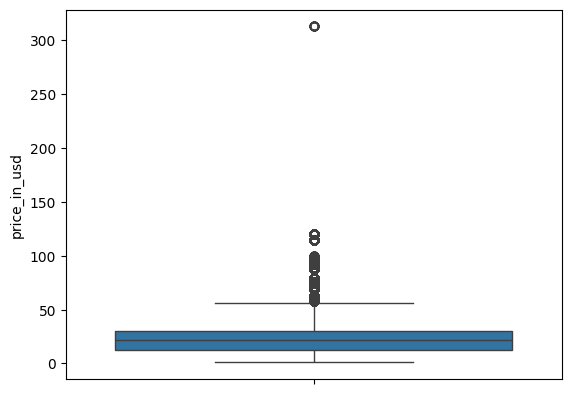

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
sns.boxplot(y=comp_data['price_in_usd'])
plt.show()

GTBT của "price_in_usd" nằm trong khoảng đâu đó từ 0 cho đến 60/70 covert được 99.7% là các GTBT

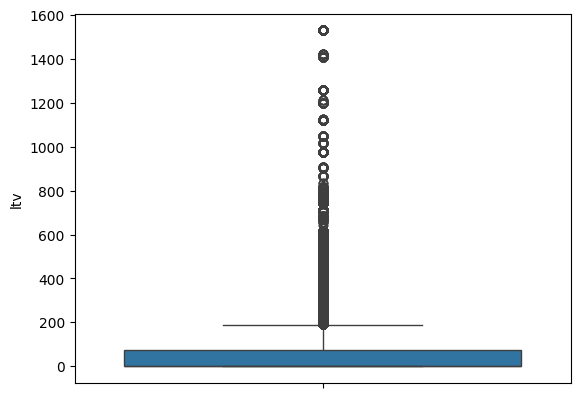

In [21]:
sns.boxplot(y=comp_data['ltv'])
plt.show()

GTBT của "ltv" từ 0 cho đến xung quanh 200

### Bivariate

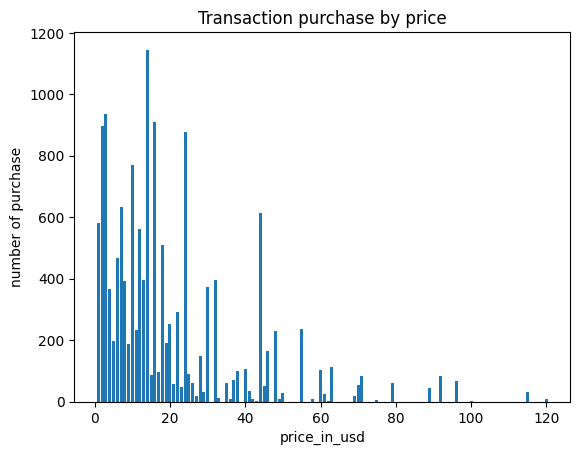

In [22]:
#data = comp_data['price_in_usd'].value_counts()
data = comp_data[comp_data['type'] == 'purchase']['price_in_usd'].value_counts()
plt.bar(data.index, data.values)
plt.xlabel("price_in_usd")
plt.ylabel("number of purchase")
plt.title("Transaction purchase by price")
plt.show()

**Nhận xét**
- Những items được mua nhiều nhất có giá dao động từ 0-30, 30-60, sau đó thì thưa dần và thấp nhất

**Đề xuất**
- Sản xuất những sản phẩm có giá trong khoảng từ 0-30, 30-60. Và chủ yếu nên tập trung vào phân khúc giá từ 0-30, còn giá 30-60 sẽ là những sản phẩm tiềm năng

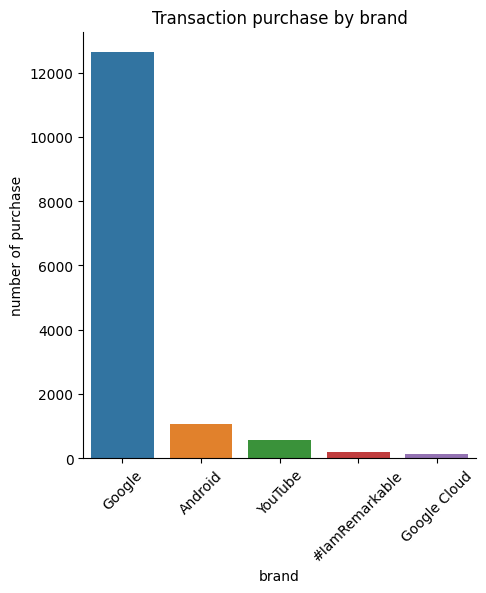

In [23]:
#sns.catplot(x = 'brand', kind = 'count', hue = 'brand', data = comp_data)
sns.catplot(x = 'brand', kind = 'count', hue = 'brand', data = comp_data[comp_data['type'] == 'purchase'])
plt.ylabel('number of purchase')
plt.title('Transaction purchase by brand')
plt.xticks(rotation=45)
plt.show()

**Nhận xét**
- Items thuộc brand Google được mua nhiều nhất. Brand Google có nhận dạng thương hiệu tốt nhất

**Đề xuất**
- Tung ra thị trường nhiều sản phẩm thuộc thương hiệu Google hơn
- Cải thiện khả năng nhận diện thương hiệu đối với các items thuộc Android và Youtube bằng các campaign quảng cáo

<ipython-input-24-30bdc01e7d8e>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-24-30bdc01e7d8e>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-24-30bdc01e7d8e>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


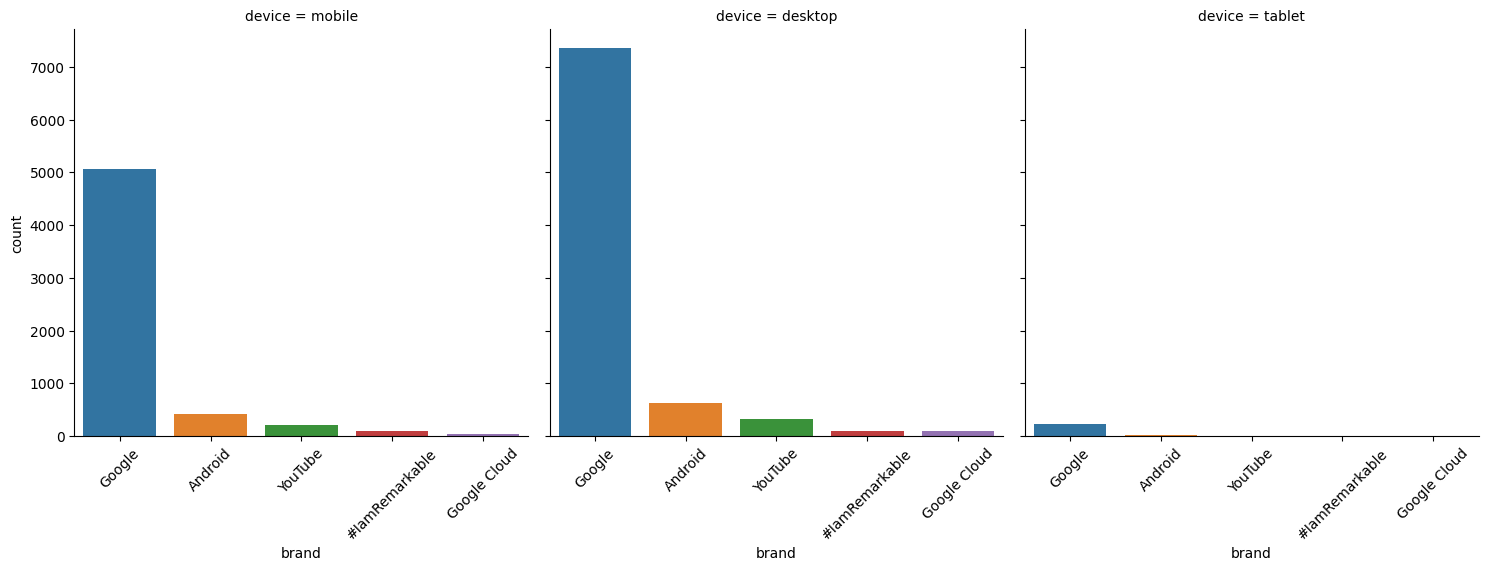

In [24]:
#g = sns.catplot(x = 'brand', kind = 'count', col = 'device', hue = 'brand', data = comp_data)
g = sns.catplot(x = 'brand', kind = 'count', col = 'device', hue = 'brand', data = comp_data[comp_data['type'] == 'purchase'])
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

**Nhận xét**
- Mặc dù trên các thiết bị khác nhau nhưng các items của brand Google vẫn được mua nhiều nhất, sau đó đến Android và Youtube. Không có sự biến đổi thứ tự so với thống kê chung ở trên
- Users sử dụng thiết bị desktop nhiều nhất, sau đó đến mobile cho nên việc users mua sản phẩm trên 2 thiết bị này theo những brand khác nhau vẫn đứng cao nhất và cao thứ hai vẫn giống so với thống kê chung

**Đề xuất**
- Chạy các campaign quảng cáo song song trên 2 nền tảng desktop và mobile. Mục đích là vừa để quảng cáo trực tiếp, vừa để quảng cáo chéo. Điều này có nghĩa là, ví dụ muốn tăng GMV đối với thiết bị mobile thì có thể chạy campaign quảng cáo kèm theo voucher được áp dụng trên mobile nhưng không được áp dụng trên desktop nên kích thích người mua tiêu dùng trên mobile

In [25]:
# Create a scatter plot using Plotly Express
import plotly.express as px
# fig = px.scatter(comp_data, x='ltv', y='price_in_usd',
#                  title='<b>Relationship between Lifetime Value and Price in USD</b>',
#                  trendline='ols')
fig = px.scatter(comp_data[comp_data['type'] == 'purchase'], x='ltv', y='price_in_usd',
                 title='<b>Relationship between Lifetime Value and Price in USD</b>',
                 trendline='ols')

fig.update_layout(
    xaxis_title='lifetime value',
    yaxis_title='price in usd',
    title_x=0.5
)

fig.show()


**Nhận xét:**
- 2 biến lifetime value và price in usd tỉ lệ thuận với nhau (nhưng chỉ là tuyến tính yếu). Khi giá trị lifetime value tăng thì người dùng chi tiền ra mua sản phẩm có giá cao hơn
- Lifetime value từ 0-400: giá trị người dùng tạo ra từ 0-400usd. price_in_usd được chi nhiều trong khoảng này là từ 0-30, từ 30-60 và > 60
- ltv tăng thì số lượng users lại giảm đáng kể. Chứng tỏ khách hàng trung thành mua hàng rất ít so với new users

**Đề xuất:**
- Đưa ra những campaign thu hút nhiều khách hàng mới
- Có những chính sách chăm sóc, giữ chân khách hàng như là hạng thành viên

#### Actions of users

             type  total_actions  percentage
0     add_to_cart         662094   92.588258
1  begin_checkout          38369    5.365581
2        purchase          14632    2.046162


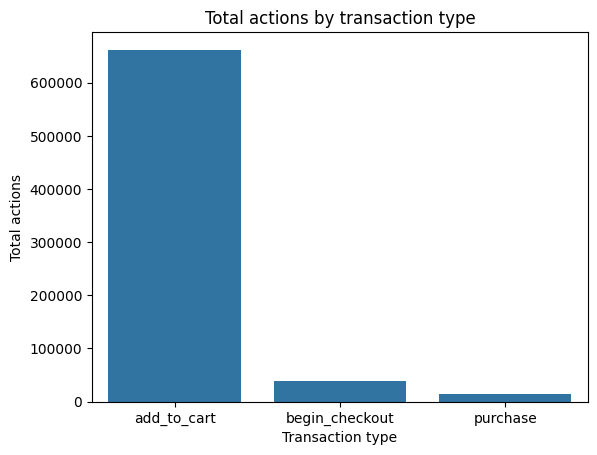

In [26]:
user_count_by_type = comp_data.groupby('type')['user_id'].count().reset_index()
user_count_by_type = user_count_by_type.rename(columns={'user_id': 'total_actions'})
user_count_by_type['percentage'] = user_count_by_type['total_actions'] *100/ user_count_by_type['total_actions'].sum()
print(user_count_by_type)

sns.barplot(x='type', y='total_actions', data=user_count_by_type)
plt.title('Total actions by transaction type')
plt.xlabel('Transaction type')
plt.ylabel('Total actions')
plt.show()


**Nhận xét**
- Type "add_to_cart" chiếm tỷ lệ cao nhất và cũng lớn nhất (92.59%) so với các type còn lại. Tuy nhiên type này không tạo ra GMV cho doanh nghiệp.
- Lí do:
  + Những sản phẩm này là những sản phẩm họ thích
  + Xem giá của sản phẩm có được ưu đãi gì không

**Đề xuất**
- Đưa ra chương trình ưu đãi phù hợp đối với những sản phẩm được add to cart nhiều (có thể tham khảo giá sản phẩm cùng loại của đối thủ cạnh tranh nếu có)
- Từ những sản phẩm mà khách hàng yêu thích có thể đề xuất thêm những sản phẩm cùng loại cho khách hàng

In [27]:
#vip users
purchase_data = comp_data[comp_data['type'] == 'purchase']
vip_users = purchase_data.groupby('user_id')['price_in_usd'].sum()
vip_users = vip_users.sort_values(ascending=False).reset_index()
print(vip_users.head())


   user_id  price_in_usd
0     7765          1410
1    11073           878
2    20451           857
3     1298           818
4    28943           781


**Đề xuất**
- Đối với những khách hàng này là những khách hàng chi nhiều tiền nhất để mua sản phẩm, nên cần có những chính sách chăm sóc khách hàng phù hợp
  + Áp dụng các hạng thành viên để tương ứng với những khách hàng thành viên có những chính sách ưu tiên riêng: kim cương, vàng, bạc, đồng để giữ chân khách hàng

In [28]:
# Items 'Add to Cart' but not purchase
add_to_cart_not_purchased = comp_data[
    (comp_data['type'] == 'add_to_cart') & (~comp_data['user_id'].isin(comp_data[comp_data['type'] == 'purchase']['user_id']))
]

add_to_cart_counts = add_to_cart_not_purchased.groupby('item_name')['user_id'].count().reset_index()
add_to_cart_counts = add_to_cart_counts.rename(columns={'user_id': 'quantity_add_to_cart'})
add_to_cart_counts = add_to_cart_counts.sort_values(by='quantity_add_to_cart',ascending=False).reset_index()

print(add_to_cart_counts[['item_name', 'quantity_add_to_cart']].head())

                         item_name  quantity_add_to_cart
0         Google Navy Speckled Tee                  7698
1            Google Zip Hoodie F/C                  7630
2           Super G Unisex Joggers                  6957
3       Google Women's Striped L/S                  6732
4  Google Campus Bike Eco Tee Navy                  6396


**Nhận xét**
- Đối với một số sản phẩm như: Google Zip Hoodie F/C được purchase nhiều nhất cũng là những sản phẩm được add to cart nhiều nhất

**Đề xuất**
- Giống như phần Total actions by transaction type

### Multivariate Analysis

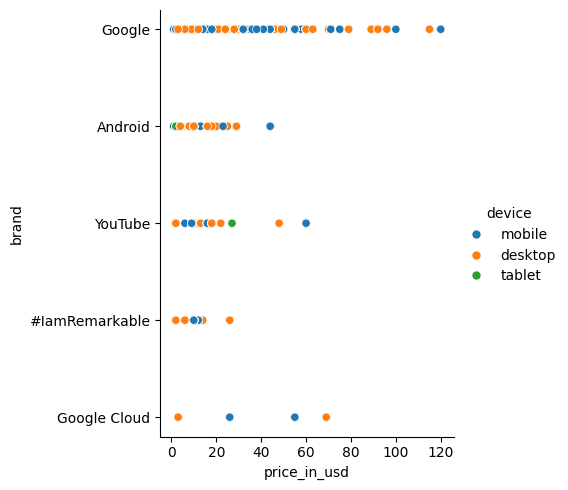

In [29]:
sns.relplot(x = 'price_in_usd', y= 'brand', hue = 'device', data = comp_data[comp_data['type'] == 'purchase'])
plt.show()

**Nhận xét:**
- Giá của items dao động từ 0-100
- Người dùng sử dụng mobile và desktop là nhiều nhất
- Họ mua hàng nhiều ở brand Google và Android

**Đề xuất:**
- Giữ giá của sản phẩm trong mức từ 0-100. Không nên bán sản phẩm với giá cao hơn
- Đảm bảo giao diện người dùng và tốc độ xử lý các session trên 2 thiết bị là mobile và desktop được tốt nhất
- Bán thêm những mặt hàng thuộc thương hiệu Google và Android

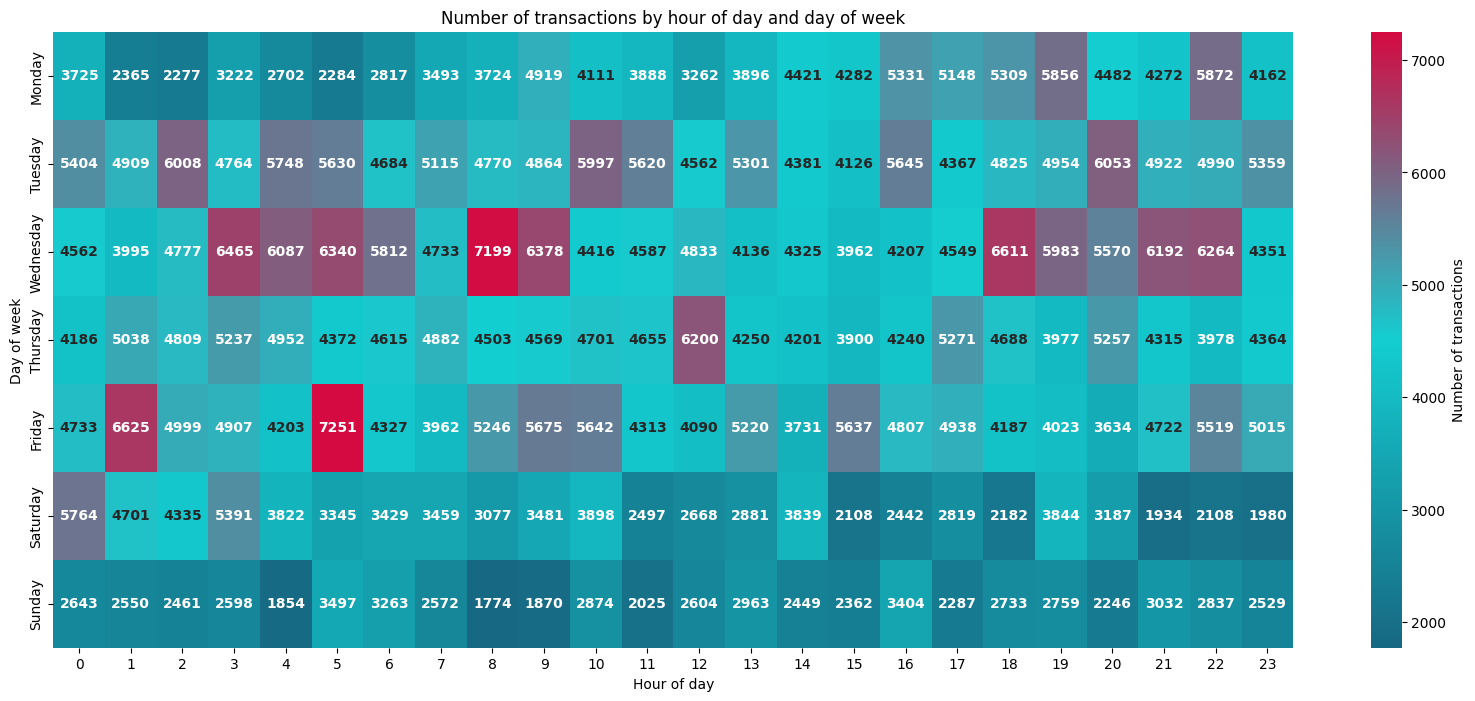

In [30]:
# Số lượng giao dịch theo giờ trong ngày và ngày trong tuần
# Tạo pivot table cho heatmap
heatmap_data = comp_data.pivot_table(values='price_in_usd', index='day_of_week', columns='hour_session', aggfunc='count', fill_value=0)

# Sắp xếp lại thứ tự của ngày trong tuần để hiển thị đúng
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

def integer_formatter(x, pos):
    return f'{int(x)}'

# Chỉnh màu
colors = ['#176882', '#13CED1', '#D50A41']
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(20, 8))
ax = sns.heatmap(heatmap_data, cmap=custom_cmap, annot=True, fmt='', cbar_kws={'label': 'Number of transactions'}, annot_kws={"size": 10, "weight": "bold"})

ax.collections[0].colorbar.ax.yaxis.set_major_formatter(FuncFormatter(integer_formatter))

plt.title('Number of transactions by hour of day and day of week')
plt.xlabel('Hour of day')
plt.ylabel('Day of week')

plt.show()

**Nhận xét:**
- Trong 3 tháng dữ liệu được thống kê thì users mua hàng nhiều nhất vào thứ 4 khung giờ từ 3-6, 8-9 và 18-22. Thứ 4 có thể là do trước dịp Giáng sinh 1 ngày
- Thứ 6 vào lúc 5h là có số lượng users mua hàng nhiều nhất. Có thể doanh thu tăng là do Black Friday

**Đề xuất:**
- Đối với những ngày, những giờ mà có users sử dụng nhiều nhất thì hệ thống nên đảm bảo để users có được trải nghiệm mua hàng tốt nhất
- Đối với những ngày, những giờ thấp điểm thì hệ thống có thể sử dụng để bảo trì

## Bước 4: Export data

In [ ]:
#Export to CSV
# comp_data.to_csv('/content/drive/MyDrive/DA_course1/Final project/comp_data_test_cohort.csv', index=False)

In [ ]:
# Export data to a Markdown file for use in NotebookLM
# with open("/content/drive/MyDrive/DA_course1/Final project/items_markdown.md", 'w') as md:
#   itm.to_markdown(buf=md, tablefmt="grid")

## Bước 5: Conversion rate (bỏ)

In [ ]:
# # Sắp xếp dữ liệu theo user_id, item_id và thời gian
# data_1 = comp_data.sort_values(by=['user_id', 'item_id', 'date_session'])

# # Nhóm dữ liệu theo user_id và item_id
# grouped_1 = data_1.groupby(['user_id', 'item_id'])

# # Hàm kiểm tra số lượng và thứ tự
# def check_conditions_1(group):
#     # Đếm số lượng các type
#     counts = group[(group['type'] == 'add_to_cart') | (group['type'] == 'begin_checkout')]['type'].value_counts()

#     # Kiểm tra số lượng add_to_cart, begin_checkout có bằng nhau hay không
#     if not all(counts.get(t, 0) == counts.get('add_to_cart', 0) for t in ['begin_checkout']):
#         return False

#     # Trích xuất danh sách type theo thứ tự thời gian
#     types = group['type'].tolist()
#     correct_order = ['add_to_cart', 'begin_checkout']

#     # Kiểm tra thứ tự
#     index = 0
#     for t in types:
#         if t == correct_order[index]:
#             index += 1
#         if index == len(correct_order):
#             return True
#     return False

# # Lọc chỉ giữ các nhóm có số lượng bằng nhau và thứ tự đúng
# valid_data_1 = grouped_1.filter(check_conditions_1)

# #conversion rate add_to_cart -> begin_checkout
# conversion_rate_1 = valid_data_1[valid_data_1['type'] == 'begin_checkout']['type'].count()/data_1[data_1['type'] == 'add_to_cart']['type'].count()
# print(conversion_rate_1*100)

**Nhận xét**
- Tỉ lệ này quá thấp, có thể do 2 lí do:
  + Trải nghiệm giỏ hàng tệ
  + Giá cả không hợp lý (quá cao)

**Đề xuất**
- Cải thiện trải nghiệm giỏ hàng của người dùng
- Đưa giá cả sản phẩm phù hợp với túi tiền của người tiêu dùng bằng các chương trình ưu đãi, khuyến mãi, đưa các voucher, mã giảm giá, free ship,...

In [ ]:
# # Sắp xếp dữ liệu theo user_id, item_id và thời gian
# data_2 = comp_data.sort_values(by=['user_id', 'item_id', 'date_session'])

# # Nhóm dữ liệu theo user_id và item_id
# grouped_2 = data_2.groupby(['user_id', 'item_id'])

# # Hàm kiểm tra số lượng và thứ tự
# def check_conditions_2(group):
#     # Đếm số lượng các type
#     counts = group[(group['type'] == 'purchase') | (group['type'] == 'begin_checkout')]['type'].value_counts()

#     # Kiểm tra số lượng begin_checkout, purchase có bằng nhau hay không
#     if not all(counts.get(t, 0) == counts.get('begin_checkout', 0) for t in ['purchase']):
#         return False

#     # Trích xuất danh sách type theo thứ tự thời gian
#     types = group['type'].tolist()
#     correct_order = ['begin_checkout', 'purchase']

#     # Kiểm tra thứ tự
#     index = 0
#     for t in types:
#         if t == correct_order[index]:
#             index += 1
#         if index == len(correct_order):
#             return True
#     return False

# # Lọc chỉ giữ các nhóm có số lượng bằng nhau và thứ tự đúng
# valid_data_2 = grouped_2.filter(check_conditions_2)



In [ ]:
# #conversion begin_checkout -> purchase
# conversion_rate_2 = valid_data_2[valid_data_2['type'] == 'purchase']['type'].count()/data_2[data_2['type'] == 'begin_checkout']['type'].count()
# print(conversion_rate_2*100)

**Nhận xét**
- Tỉ lệ trên 11% có thể tạm chấp nhận được. Tuy nhiên, có thể do những lí do sau mà tỉ lệ này chưa cao:
  + Phương thức thanh toán chưa đa dạng
  + Thủ tục thanh toán còn rườm rà, nhiều bước

**Đề xuất**
- Đa dạng phương thức thanh toán: visa, credit-card, ví điện tử, tài khoản ngân hàng, thanh toán trực tiếp,...
- Cải thiện trải nghiệm thanh toán của người dùng

Lí do bỏ: Dữ liệu chỉ trong 3 tháng 11/2020, 12/2020 và 1/2021 nên nếu giả sử quá trình mua hàng theo các bước 1. add_to_cart => 2. begin_checkout => 3. purchase thì sẽ không đầy đủ dữ liệu để kết luận giả thuyết trên là đúng hay sai. Vì có những users chỉ có type là purchase mà không tồn tại add_to_cart hay begin_checkout, điều này có thể giải thích là do họ thực hiện các bước này trước vào 11/2020. Hoặc có những users chỉ có type begin_checkout nhưng không có type add_to_cart hoặc purchase, đều này cũng có thể giải thích họ thực hiện add_to_cart trước 11/2020 và purchase sau 1/2021. Tuy nhiên, nếu điều đó đúng thì cũng không thể tính conversion rate. Bởi vì, không thể xác định được là trong 3 tháng này thì họ thực hiện begin_checkout cho sản phẩm vừa được add_to_cart, hay là đã được add_to_cart trước thời gian được thống kê. Đề xuất bổ sung thêm dữ liệu:
+ Thông tin sản phẩm có trong giỏ hàng (số lượng, item_id, mã code,...)
+ Id của mỗi event